## 📐 Obstruction calculation


In [2]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import sys
import importlib

# Add current directory to path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Import and reload to get latest changes
import viz_utils
import sample_constructions
importlib.reload(viz_utils)
importlib.reload(sample_constructions)

from viz_utils import (HorizonAngleVisualizer, ZenithAngleVisualizer, 
                       CombinedObstructionVisualizer, DirectionVectorCalculator)
from sample_constructions import StandardScenarios

### 📡Setup Server Connection

Start the server: 

`python -m src.main`

In [ ]:
SERVER_URL = "http://localhost:8081"
response = requests.get(f"{SERVER_URL}/")
print("Server Status:", response.json())

Server Status: {'services': {'raytrace_service': {'horizon_calculator': 'MaxHeightObstructionCalculator', 'projection_calculator': 'OrthographicProjectionCalculator', 'status': 'ready', 'zenith_calculator': 'ZenithAngleCalculator'}}, 'status': 'running'}


### 👉 Scenario construction

In [18]:
# request construction example
window_center = [0.0, 3.0, 0.0]
window_angles = [0.03, 0.0]  # Looking forward (+X)
building_dist, building_height, building_width = 10.0, 5.0, 10.0
mesh = [[10, 0.0, -5], [10, 5, -5], [10, 0.0, 5],
        [10, 0.0, 5], [10, 5, -5], [10, 5, 5]]


### 👉 Horizon angle

In [19]:
# Create vertical building scenario
scenario = StandardScenarios.vertical_building(
    window_height=3.0,
    building_distance=10.0,
    building_height=5.0,
    building_width=10.0
)

window_center = scenario.window_center
window_angles = scenario.window_angles
mesh = scenario.get_combined_mesh()

print(f"Window: {window_center}, Angles: {window_angles}")
print(f"Building: 10.0m away, 5.0m tall, 10.0m wide")

Window: [0.0, 3.0, 0.0], Angles: [0.03, 0.0]
Building: 10.0m away, 5.0m tall, 10.0m wide


In [20]:
request_data = scenario.to_request_data()
response = requests.post(f"{SERVER_URL}/horizon_angle", json=request_data)
result = response.json()
print("Result:", result)

Result: {'data': {'highest_point': {'x': 10.0, 'y': 5.0, 'z': -5.0}, 'obstruction_angle_degrees': 11.309932474020213, 'obstruction_angle_radians': 0.19739555984988075, 'projected_point_count': 6}, 'status': 'success'}


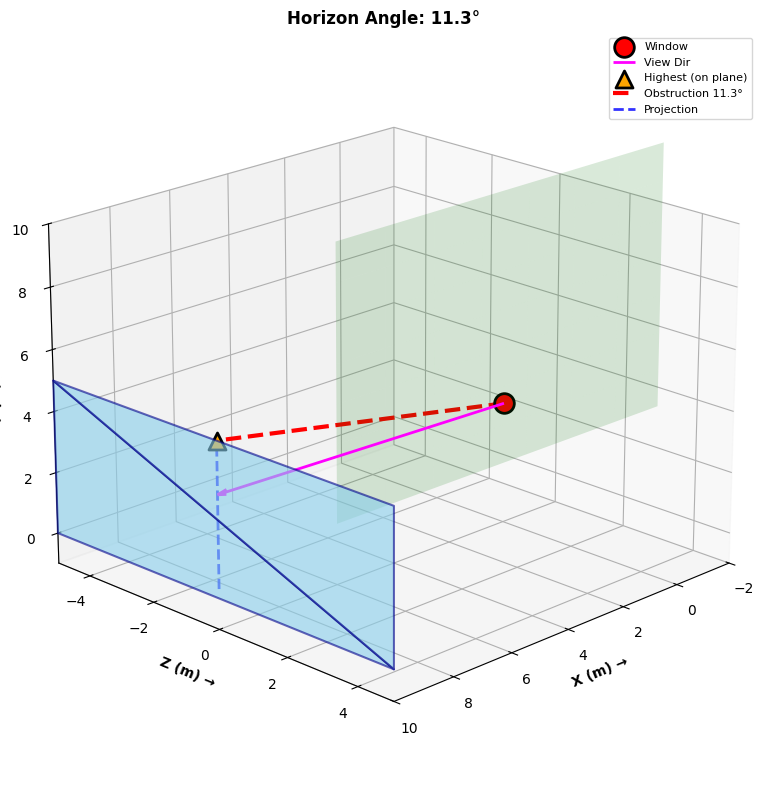

In [21]:
if result.get("status") == "success":
    data = result["data"]
    obstruction_degrees, obstruction_radians, highest_point = data["obstruction_angle_degrees"], data["obstruction_angle_radians"], data["highest_point"]
    # Create visualizer
    visualizer = HorizonAngleVisualizer(
        window_center=window_center,
        window_angles=window_angles,
        mesh_vertices=mesh,
        building_dimensions=(building_dist, building_height, building_width)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, highest_point, obstruction_degrees)
    plt.tight_layout()
    plt.show()

### 👉 Zenith Angle Calculation

In [22]:
# Test zenith angle with the same building
response = requests.post(f"{SERVER_URL}/zenith_angle", json=request_data)
zenith_result = response.json()
print("Zenith Result:", zenith_result)

if zenith_result.get("status") == "success":
    data = zenith_result["data"]
    zenith_degrees = data["obstruction_angle_degrees"]
    zenith_radians = data["obstruction_angle_radians"]
    

Zenith Result: {'data': {'highest_point': None, 'obstruction_angle_degrees': 0.0, 'obstruction_angle_radians': 0.0, 'projected_point_count': 6}, 'status': 'success'}


### 👉 Overhead Obstruction Example

In [23]:
# Create horizontal overhead scenario
overhead_scenario = StandardScenarios.horizontal_overhead(
    window_height=3.0,
    roof_start=5.0,
    roof_end=8.0,
    roof_height=7.0,
    roof_width=4.0
)

overhead_request = overhead_scenario.to_request_data()

# Calculate zenith angle
response = requests.post(f"{SERVER_URL}/zenith_angle", json=overhead_request)
overhead_result = response.json()

if overhead_result.get("status") == "success":
    data = overhead_result["data"]
    zenith_deg = data["obstruction_angle_degrees"]
    lowest_pt = data["highest_point"]
    
    print(f"Zenith Angle: {zenith_deg:.2f}°")
    if zenith_deg > 0:
        print(f"Furthest overhead point: ({lowest_pt['x']:.1f}, {lowest_pt['y']:.1f}, {lowest_pt['z']:.1f})")
    else:
        print("No overhead obstruction found on direction plane")
else:
    print("ERROR:", overhead_result.get("error"))

Zenith Angle: 63.43°
Furthest overhead point: (8.0, 7.0, -2.0)


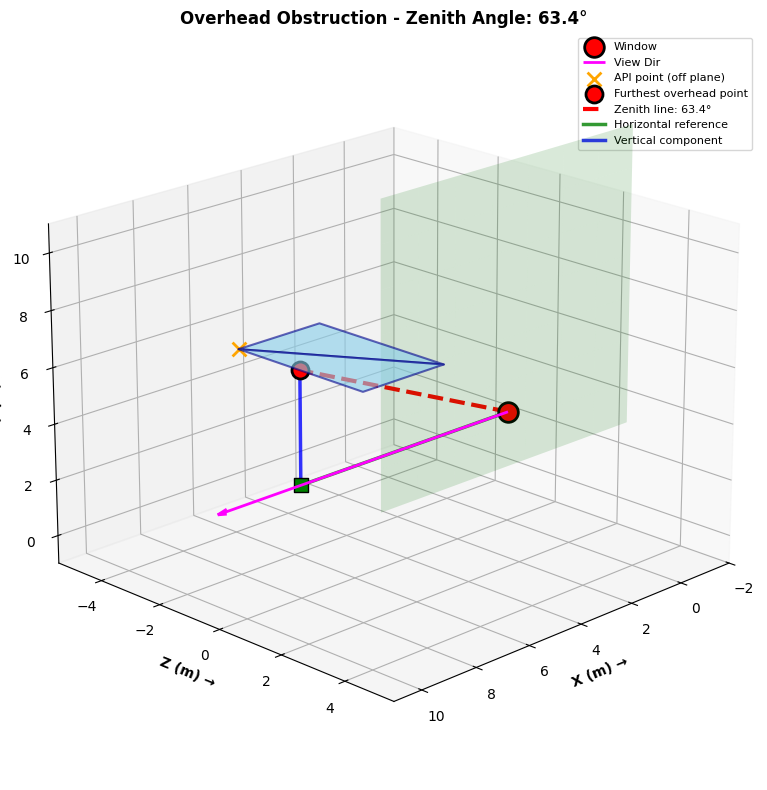

In [24]:
if overhead_result.get("status") == "success" and zenith_deg > 0:
    # Create visualizer
    visualizer = ZenithAngleVisualizer(
        window_center=overhead_scenario.window_center,
        window_angles=overhead_scenario.window_angles,
        mesh_vertices=overhead_scenario.get_combined_mesh(),
        scene_dimensions=(8.0, 7.0, 4.0)
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, lowest_pt, zenith_deg)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - no overhead obstruction found")

### 👉 Obstruction (Both Angles)

Use the `/obstruction` endpoint to calculate both horizon and zenith angles in a single request.

In [25]:
# Create mixed scenario with both vertical and horizontal obstructions
mixed_scenario = StandardScenarios.mixed_obstruction(window_height=3.0)

# Get obstruction angles for both
response = requests.post(f"{SERVER_URL}/obstruction", json=mixed_scenario.to_request_data())
both_result = response.json()

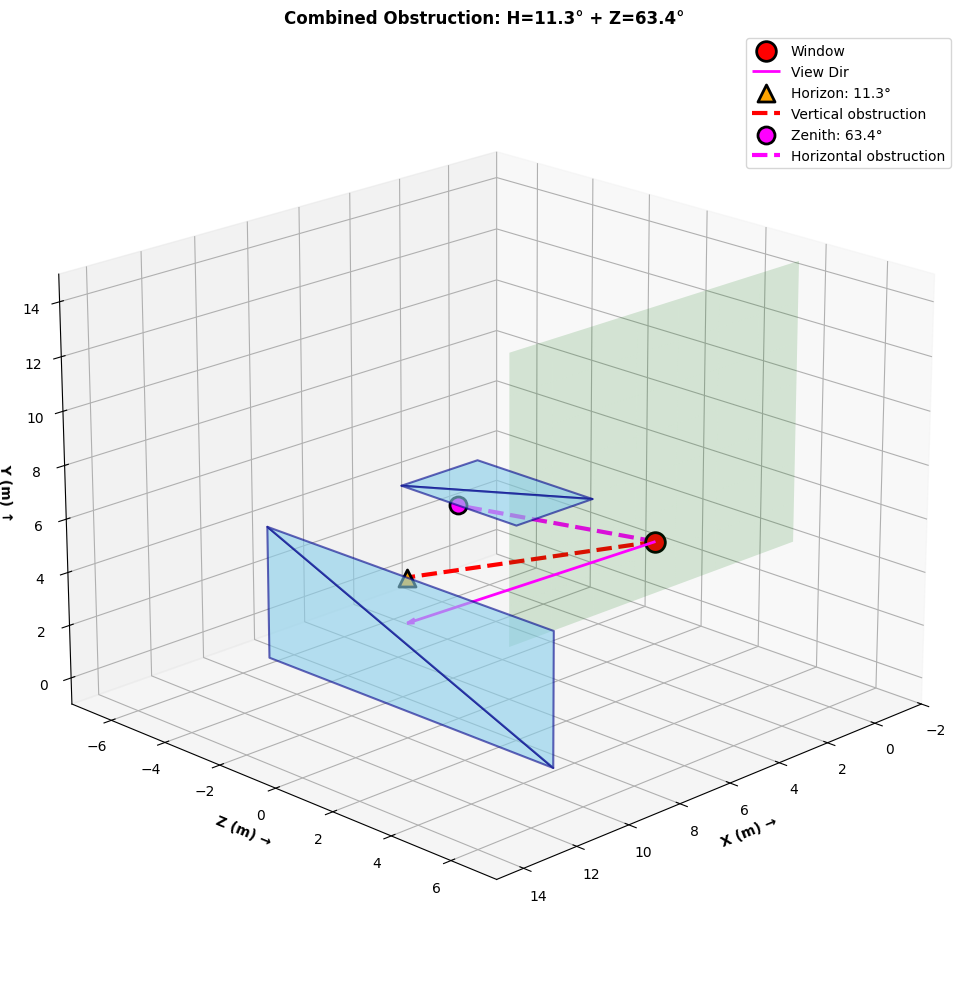

In [26]:
if both_result.get("status") == "success":
    # Extract data
    horizon_data = both_result["data"]["horizon"]
    zenith_data = both_result["data"]["zenith"]
    
    # Create combined visualizer
    visualizer = CombinedObstructionVisualizer(
        window_center=mixed_scenario.window_center,
        window_angles=mixed_scenario.window_angles,
        mesh_vertices=mixed_scenario.get_combined_mesh()
    )
    
    # Create figure and visualize
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    visualizer.visualize(ax, horizon_data, zenith_data)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping visualization - obstruction calculation failed")